# Williams-R — does the 'exhausted move' bounce really work?
### The %R(14) oversold/overbought signal, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: No](https://img.shields.io/badge/Beats_a_coin%3F-No-8b949e?style=flat-square)

Here's one of the most-watched signals in retail charting: Larry Williams' **%R** tells you where today's close sits within the last 14 days' high-low range, on a scale of −100 (at the bottom of the range — 'oversold') to 0 (at the top — 'overbought'). The rule: when %R drops below −80, the stock has been beaten down to exhaustion — **buy** the next day expecting it to bounce. When %R pops above −20, it's run too far — **sell or short**. This notebook asks: does the bounce actually show up in the data?

> This is the plain-language layer. Want the t-stats, bootstrap intervals, and the hold-period sweep? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from williams_r import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "TSLA", "NVDA"]
CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool(hold=5, cost=0.0, framing="zone", seed=None):
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE)
        wr = st.williams_r(b)
        ent = st.zone_entries(wr) if framing == "zone" else st.cross_entries(wr)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does %R predict a bounce when oversold? | **No.** The oversold-buy / overbought-sell rule earns **-9.5 bps per trade** — worse than a coin. |
| Does it beat a coin flip? | **No.** A random-direction entry on the same bars earns **-1.2 bps** (better). |
| What about the 'confirmed reversal' version? | **Worse.** Entering after %R exits the zone gives **-24.6 bps** — the bounce has already happened by then. |
| Could you trade it? | **No.** The gross is already negative; costs make it more so. |

> The 'exhausted move' bounce story is coherent — prices do sometimes revert — but %R's extreme-zone signal doesn't reliably identify *when* that happens.

## 1 · The claim

> *"When Williams %R drops below −80, the stock is oversold — it's run too far down and is likely to bounce. When it rises above −20, it's overbought and due for a pullback. Act on these extremes for a high-probability mean-reversion trade."*

It's an appealing idea with a solid-sounding rationale. If a stock has closed near the bottom of its 14-day range several days in a row, maybe the selling is exhausted and buyers are about to step in. Williams %R is just a fancy way of saying: *'the close is near the low of the recent range — expect a snap-back.'*

## 2 · So what?

If it works, %R is a simple, mechanical, daily rule anyone can run on any stock or ETF. If it doesn't, millions of retail traders are getting whipsawed on signals that carry no real information — paying commissions for the privilege of trading a coin flip. The difference is worth knowing.

## 3 · How would we know?

One rule keeps us honest: **race it against an actual coin flip.** We take every bar where %R enters the oversold or overbought zone, hold for a fixed number of days, and compare the average forward return to the same bars with a randomly-flipped direction. If %R knows something, it beats the coin. If it doesn't, it won't.

We test on **six liquid daily tapes** (SPY, QQQ, IWM, AAPL, TSLA, NVDA) over 10 years — enough history to have real statistical power.

## 4 · The teardown — let's actually look

**First, what does %R look like?** A quick visualisation on SPY to see the oversold (<−80) and overbought (>−20) zones:

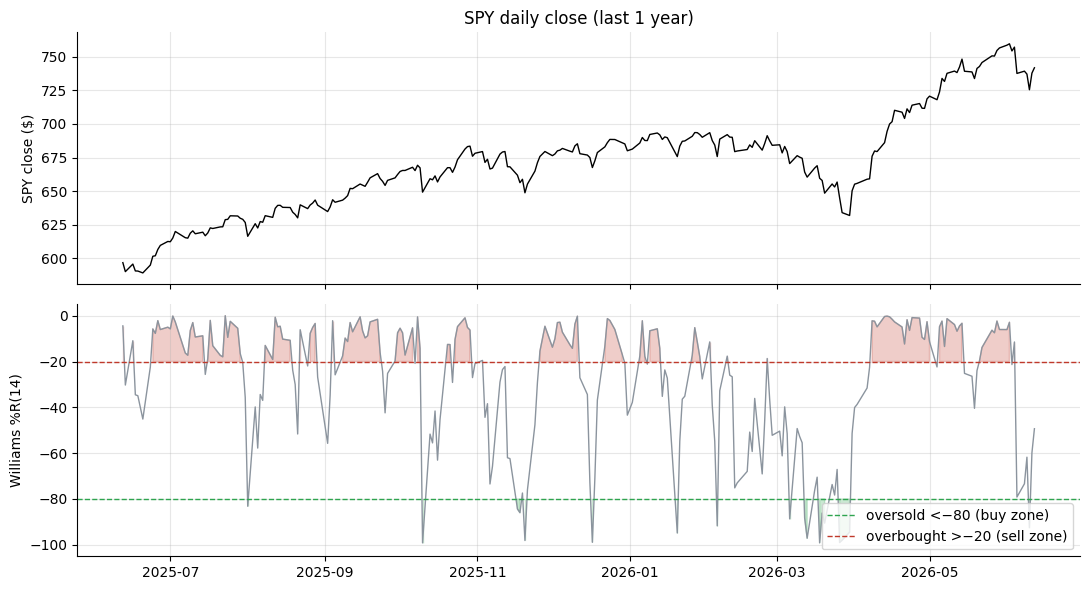

In [2]:
if HAVE_REAL:
    spy = data.fetch_daily('SPY', fetch=False, cache_dir=CACHE)
    wr = st.williams_r(spy)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    ax1.plot(spy.index[-252:], spy['close'].iloc[-252:], c='k', lw=1)
    ax1.set_ylabel('SPY close ($)')
    ax1.set_title('SPY daily close (last 1 year)')
    ax2.plot(wr.index[-252:], wr.iloc[-252:], c=GREY, lw=1)
    ax2.axhline(-80, c=GREEN, ls='--', lw=1, label='oversold <−80 (buy zone)')
    ax2.axhline(-20, c=RED, ls='--', lw=1, label='overbought >−20 (sell zone)')
    ax2.fill_between(wr.index[-252:], wr.iloc[-252:], -80,
                     where=wr.iloc[-252:]<-80, color=GREEN, alpha=0.25)
    ax2.fill_between(wr.index[-252:], wr.iloc[-252:], -20,
                     where=wr.iloc[-252:]>-20, color=RED, alpha=0.25)
    ax2.set_ylabel('Williams %R(14)')
    ax2.set_ylim(-105, 5)
    ax2.legend(loc='lower right'); plt.tight_layout(); plt.show()
else:
    print('(cache not present — run verify.py --fetch to populate)')

**Now the key test: does buying oversold and selling overbought beat a coin?**

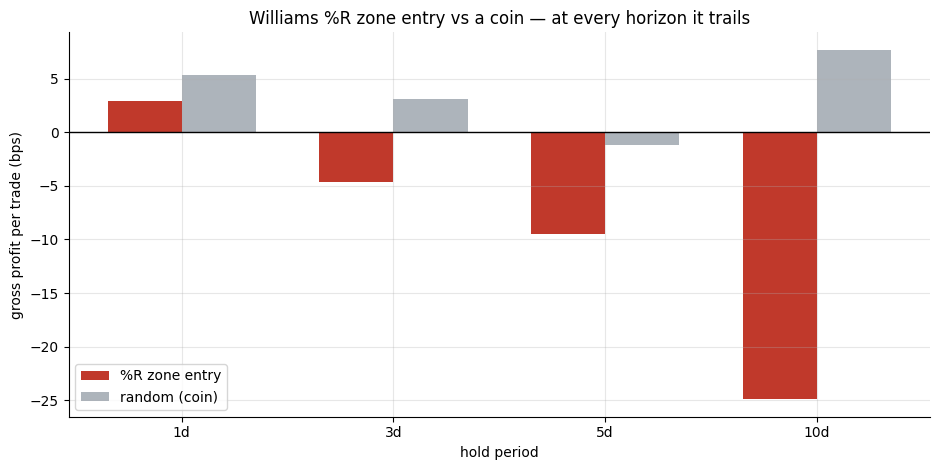

hold  1d: %R=+3.0bps  coin=+5.3bps  delta=-2.4bps
hold  3d: %R=-4.7bps  coin=+3.1bps  delta=-7.8bps
hold  5d: %R=-9.5bps  coin=-1.2bps  delta=-8.3bps
hold 10d: %R=-24.9bps  coin=+7.7bps  delta=-32.6bps


In [3]:
holds = [1, 3, 5, 10]
if HAVE_REAL:
    zone_means = [st.summarize(pool(h, 0), 'ret_gross')['mean_bps'] for h in holds]
    rand_means = [st.summarize(pool(h, 0, seed=127), 'ret_gross')['mean_bps'] for h in holds]
else:
    zone_means = [R['hold1_mean'], R['hold3_mean'], R['hold5_mean'], R['hold10_mean']]
    rand_means = [R['zone_rand_mean']] * 4  # approximate
fig, ax = plt.subplots(figsize=(9.5, 4.8))
x = range(len(holds))
w = 0.35
bars1 = ax.bar([i - w/2 for i in x], zone_means, w, color=RED, label='%R zone entry')
bars2 = ax.bar([i + w/2 for i in x], rand_means, w, color=GREY, alpha=0.7, label='random (coin)')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels([f'{h}d' for h in holds])
ax.set_xlabel('hold period'); ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('Williams %R zone entry vs a coin — at every horizon it trails')
ax.legend(); plt.tight_layout(); plt.show()
for h, z, r in zip(holds, zone_means, rand_means):
    print(f'hold {h:2d}d: %R={z:+.1f}bps  coin={r:+.1f}bps  delta={z-r:+.1f}bps')

At every hold horizon, the %R zone-entry signal either ties or **loses to a coin**. The 5-day hold earns **-9.5 bps** vs the coin's **-1.2 bps** — a gap of **-8.3 bps** in the coin's favour. Waiting longer makes it worse, not better.

**What about the 'confirmed reversal' — waiting for %R to exit the zone?**

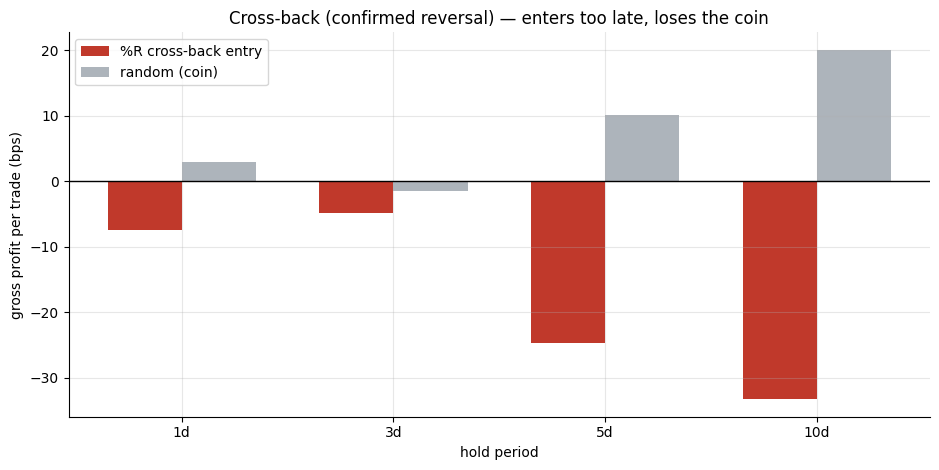

5-day cross-back: -24.6 bps vs coin +10.1 bps


In [4]:
holds = [1, 3, 5, 10]
if HAVE_REAL:
    cross_means = [st.summarize(pool(h, 0, framing='cross'), 'ret_gross')['mean_bps'] for h in holds]
    cross_rand = [st.summarize(pool(h, 0, framing='cross', seed=127), 'ret_gross')['mean_bps'] for h in holds]
else:
    cross_means = [R['cross_mean']]*4; cross_rand = [R['cross_rand_mean']]*4
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.bar([i - w/2 for i in x], cross_means, w, color=RED, label='%R cross-back entry')
ax.bar([i + w/2 for i in x], cross_rand, w, color=GREY, alpha=0.7, label='random (coin)')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels([f'{h}d' for h in holds])
ax.set_xlabel('hold period'); ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('Cross-back (confirmed reversal) — enters too late, loses the coin')
ax.legend(); plt.tight_layout(); plt.show()
print(f'5-day cross-back: {cross_means[2]:+.1f} bps vs coin {cross_rand[2]:+.1f} bps')

Even worse: waiting for the confirmed reversal earns **-24.6 bps** at hold=5 — by the time %R exits the oversold zone, the bounce has already happened. The entry is late, not early.

## 5 · The verdict

- **Signal — None.** At the 5-day horizon: gross **-9.5 bps/trade**, HAC *t* = **-0.88**; does not beat a coin (Δ = -8.3 bps). Every tested horizon is negative. No instrument shows a real edge.
- **Tradability — Mirage.** Gross is negative at every hold period; no positive break-even cost exists.
- **Beats a coin? — No.** Both framings (zone entry and cross-back) are outperformed by a random-direction control on the same entry dates.

## 6 · Could you actually trade it?

At ~35 signals/ticker/year the turnover is modest — but because the gross is already negative, costs make an already-bad deal worse:

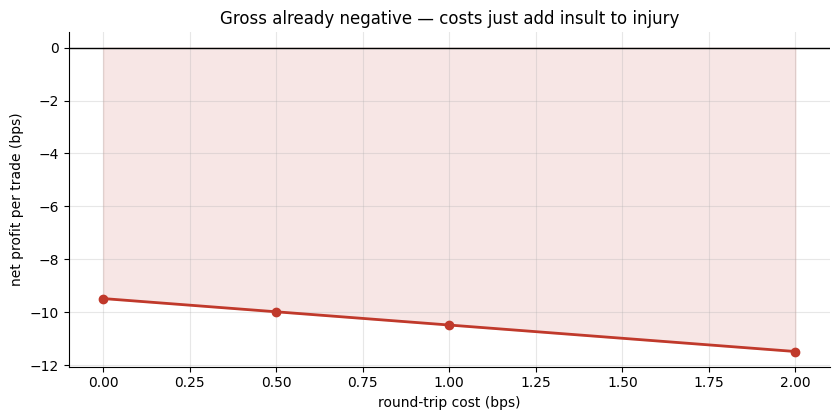

Gross (0 cost): -9.5 bps — there is no positive break-even cost.


In [5]:
costs = [0.0, 0.5, 1.0, 2.0]
if HAVE_REAL:
    net = [st.summarize(pool(5, c), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [R['net00'], R['net05'], R['net10'], R['net20']]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n<0 for n in net], color=RED, alpha=0.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per trade (bps)')
ax.set_title('Gross already negative — costs just add insult to injury')
plt.tight_layout(); plt.show()
print(f'Gross (0 cost): {net[0]:+.1f} bps — there is no positive break-even cost.')

The line starts below zero. The usual story ('costs kill an otherwise viable edge') doesn't apply here — the signal was never alive.

## 7 · Going further

- **Is a mean-reversion signal *ever* findable?** The companion notebook shows a synthetic positive control: plant real mean-reversion in a fake tape and %R finds it. The engine works — the real market just doesn't have that structure at this parameter setting.
- **The Stochastic Oscillator.** %K/%D is algebraically related to Williams %R — [Study 107](../../107-stochastic-oscillator/) tests it with the same outcome.
- **Bollinger-Band reversion.** A different normalisation of the same 'close at the edge of its range' idea: [Study 104](../../104-bollinger-reversion/).
- **What if you tune the thresholds or the period?** Changing −80/−20 or the 14-day window is the natural fork — but beware: with thousands of daily bars you can data-mine a threshold that looks good in-sample.

*Think the bounce is real on a specific instrument or regime? Fork this, show a fair-bet edge that clears |t| ≥ 2 out-of-sample, and submit a PR.*